In [1]:
import warnings
import matplotlib.pyplot as plt
import numpy as np

import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from torch.utils.data import Dataset, DataLoader

import warnings
warnings.filterwarnings("ignore")

In [2]:
SEED = 42
PLOT_DPI = 100

TRAIN_DATA_PATH = "../data/preprocessed_skab_dataset_train_undersampled_smote_fe.csv"
TEST_DATA_PATH = "../data/preprocessed_skab_dataset_fe_test.csv"

In [3]:
def read_dataframe(path: str) -> pd.DataFrame:
    """
    Reads a CSV file into a pandas DataFrame and processes the 'datetime' column if it exists.
    
    Args:
        path (str): The file path to the CSV file.
        
    Returns:
        pd.DataFrame: The processed DataFrame.
    """
    dataframe = pd.read_csv(path)
    if "datetime" in dataframe.columns:
        dataframe.set_index(pd.to_datetime(dataframe.datetime), drop=True, inplace=True)
        dataframe.drop(columns=["datetime"], inplace=True)

    # dataframe = dataframe.iloc[np.where(dataframe.anomaly != 0)]
    # dataframe["anomaly"] = dataframe["anomaly"]-1

    return dataframe

In [4]:
dataframe_train = read_dataframe(TRAIN_DATA_PATH)

columns = ["Accelerometer1RMS", "Accelerometer2RMS", "Current", "Pressure", "Temperature", "Thermocouple", "Voltage", "Volume Flow RateRMS", "anomaly", "description"]
dataframe_train = dataframe_train[columns]
dataframe_train

tmp = dataframe_train.drop(columns=["anomaly", "description"], axis=1)

scaler = StandardScaler()
# scaler = MinMaxScaler(feature_range=(-1, 1))

dataframe_train_scaled = scaler.fit_transform(tmp)
dataframe_train_scaled = pd.DataFrame(dataframe_train_scaled, columns=tmp.columns)
dataframe_train_scaled.index = tmp.index
dataframe_train_scaled = pd.concat([dataframe_train_scaled, dataframe_train[["anomaly", "description"]]], axis=1)

dataframe_train_scaled
# dataframe_train.head()

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,anomaly,description
0,-0.330334,-0.313927,1.236586,-0.188610,0.725076,0.146169,-0.152574,0.654383,0.0,No Anomaly
1,-1.244971,-1.299616,-1.009370,1.307826,-2.237591,-1.273270,1.867961,-1.513511,0.0,No Anomaly
2,-0.356821,-0.346745,0.152848,2.817920,0.631842,0.400604,-0.099355,0.654383,0.0,No Anomaly
3,-0.159102,-0.193980,1.275468,-0.188610,0.329092,0.105539,0.402748,0.631325,0.0,No Anomaly
4,-0.989547,-0.917715,-0.821112,-1.753445,0.480131,-2.168341,0.596340,-0.498513,0.0,No Anomaly
...,...,...,...,...,...,...,...,...,...,...
315191,-1.249166,-1.304602,-1.389484,-2.015720,-2.018707,-1.420216,0.888304,-1.536963,13.0,Outlet Valve Malfunction
315192,-1.248400,-1.307080,-1.837579,-0.195439,-2.142214,-1.497146,0.345406,-1.606289,13.0,Outlet Valve Malfunction
315193,-1.248420,-1.315082,-1.664568,-0.008068,-2.250555,-1.447758,-0.026083,-1.606078,13.0,Outlet Valve Malfunction
315194,-1.248434,-1.307764,-2.086406,-0.195439,-2.235416,-1.477578,0.991127,-1.544793,13.0,Outlet Valve Malfunction


In [5]:
dataframe_train_scaled.anomaly.value_counts()

anomaly
0.0     22514
12.0    22514
8.0     22514
11.0    22514
13.0    22514
2.0     22514
1.0     22514
5.0     22514
3.0     22514
6.0     22514
4.0     22514
9.0     22514
10.0    22514
7.0     22514
Name: count, dtype: int64

In [6]:
# dataframe_test = read_dataframe(TEST_DATA_PATH)
# dataframe_test = dataframe_test[columns]
# dataframe_test

# tmp = dataframe_test.drop(columns=["anomaly", "description"], axis=1)

# dataframe_test_scaled = scaler.transform(tmp)
# dataframe_test_scaled = pd.DataFrame(dataframe_test_scaled, columns=tmp.columns)
# dataframe_test_scaled.index = tmp.index
# dataframe_test_scaled = pd.concat([dataframe_test_scaled, dataframe_test[["anomaly", "description"]]], axis=1)

# dataframe_test_scaled.head()
# # dataframe_test.head()

In [7]:
BATCH_SIZE = 512
N_CLASSES = 14

In [8]:
class SKABDataset(Dataset):
    """
    A custom PyTorch Dataset for loading numerical data from a CSV file.
    """
    def __init__(self, dataframe: pd.DataFrame):

        self.__dataframe = dataframe.copy()

        if "datetime" in self.__dataframe.columns:
            self.__dataframe.set_index(pd.to_datetime(self.__dataframe.datetime), drop=True, inplace=True)
            self.__dataframe.drop(columns=["datetime"], inplace=True)

        self.__dataframe_anomaly = self.__dataframe[["anomaly"]]
        self.__dataframe_description = self.__dataframe[["description"]]
        self.__dataframe = self.__dataframe.drop(["anomaly", "description"], axis=1)

    def __len__(self):
        return len(self.__dataframe_anomaly)
    
    def __getitem__(self, idx):
        data = torch.tensor(self.__dataframe.iloc[idx].values, dtype=torch.float32)
        target = torch.tensor(self.__dataframe_anomaly.iloc[idx].values, dtype=torch.int64)
        return data, target

train_dataloader = DataLoader(
                                SKABDataset(dataframe=dataframe_train_scaled),
                                batch_size=BATCH_SIZE, shuffle=True, drop_last=True
)

# test_dataloader = DataLoader(
#                                 SKABDataset(dataframe=dataframe_test_scaled),
#                                 batch_size=1, shuffle=True, drop_last=True
# )


for batch_id, (data, target) in enumerate(train_dataloader, 1):
    print(batch_id, data.shape, target.shape)
    break

# for batch_id, (data, target) in enumerate(test_dataloader, 1):
#     print(batch_id, data.shape, target.shape)
#     break

1 torch.Size([512, 8]) torch.Size([512, 1])


### Conditional Wesserstein GAN

In [41]:
EPOCHS = 10
LEARNING_RATE_CRITIC, LEARNING_RATE_GENERATOR = 0.001, 0.001

NOISE_DIMENSION, FEATURE_SIZE = 64, 8
LABEL_EMBEDDING_G, LABEL_EMBEDDING_C = 64, 64

CRITIC_ITERATIONS = 3
LAMBDA_GP = 10

USE_SN = False # Use Spectral Normalization
L1_REGULARIZATION_C, L2_REGULARIZATION_C = False, False
L1_REGULARIZATION_G, L2_REGULARIZATION_G = False, False

DEVICE = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

np.random.seed(SEED)

DEVICE

device(type='cuda')

In [42]:
def gradient_penalty(critic, labels, real, fake, device="cpu"):
    BATCH_SIZE, FEATURE_SIZE = real.shape

    alpha = torch.rand((BATCH_SIZE, 1)).repeat(1, FEATURE_SIZE).to(device)
    interpolated_samples = real * alpha + fake * (1 - alpha)

    # Calculate critic scores
    mixed_scores = critic(interpolated_samples, labels)

    # Take the gradient of the scores with respect to the images
    gradient = torch.autograd.grad(
                                        inputs=interpolated_samples,
                                        outputs=mixed_scores,
                                        grad_outputs=torch.ones_like(mixed_scores),
                                        create_graph=True,
                                        retain_graph=True,
    )[0]
    gradient = gradient.view(gradient.shape[0], -1)
    gradient_norm = gradient.norm(2, dim=1)
    gradient_penalty = torch.mean((gradient_norm - 1) ** 2)
    return gradient_penalty

In [43]:
class LayerNormalization(nn.Module):
    def __init__(self, features: int, eps:float=10**-6) -> None:
        super().__init__()
        self.eps = eps
        self.alpha = nn.Parameter(torch.ones(features)) # alpha is a learnable parameter
        self.bias = nn.Parameter(torch.zeros(features)) # bias is a learnable parameter

    def forward(self, x):
        # x: (batch, seq_len, hidden_size)
         # Keep the dimension for broadcasting
        mean = x.mean(dim = -1, keepdim = True) # (batch, seq_len, 1)
        # Keep the dimension for broadcasting
        std = x.std(dim = -1, keepdim = True) # (batch, seq_len, 1)
        # eps is to prevent dividing by zero or when std is very small
        return self.alpha * (x - mean) / (std + self.eps) + self.bias
    
class ResidualConnection(nn.Module):
        def __init__(self, features: int, dropout: float) -> None:
            super().__init__()
            self.dropout = nn.Dropout(dropout)
            self.norm = LayerNormalization(features)
    
        def forward(self, x, sublayer):
            # return x + self.dropout(sublayer(self.norm(x)))
            return self.dropout(self.norm(x + sublayer(x)))

class MultiHeadAttentionBlock(nn.Module):
    def __init__(self, d_model: int, h: int, dropout: float) -> None:
        super().__init__()
        self.d_model = d_model # Embedding vector size
        self.h = h # Number of heads
        # Make sure d_model is divisible by h
        assert d_model % h == 0, "d_model is not divisible by h"

        self.d_k = d_model // h # Dimension of vector seen by each head
        self.w_q = nn.Linear(self.d_model, self.d_model, bias=False) # Wq
        self.w_k = nn.Linear(self.d_model, self.d_model, bias=False) # Wk
        self.w_v = nn.Linear(self.d_model, self.d_model, bias=False) # Wv
        self.w_o = nn.Linear(self.d_model, self.d_model, bias=False) # Wo
        self.dropout = nn.Dropout(dropout)

        self.training_mask = None
        self.inferencing_mask = None

    def attention(self, query, key, value, apply_mask, dropout: nn.Dropout):
        d_k = query.shape[-1]

        # Just apply the formula from the paper
        # (batch, h, seq_len, d_k) --> (batch, h, seq_len, seq_len)
        attention_scores = (query @ key.transpose(-2, -1)) / np.sqrt(d_k)
        
        if apply_mask:
            if self.training:
                if self.training_mask is None:
                    self.training_mask = torch.from_numpy(np.zeros(attention_scores.shape)).float()
                    for batch in range(attention_scores.shape[0]):
                        for head in range(attention_scores.shape[1]):
                            self.training_mask[batch][head][np.triu_indices(attention_scores.shape[-1], 1)] = -np.inf
                    self.training_mask = self.training_mask.to(DEVICE)
                attention_scores = attention_scores + self.training_mask
            else:
                self.inferencing_mask = torch.from_numpy(np.zeros(attention_scores.shape)).float()
                for batch in range(attention_scores.shape[0]):
                    for head in range(attention_scores.shape[1]):
                        self.inferencing_mask[batch][head][np.triu_indices(attention_scores.shape[-1], 1)] = -np.inf
                    self.inferencing_mask = self.inferencing_mask.to(DEVICE)
                attention_scores = attention_scores + self.inferencing_mask
        
        # attention_scores = attention_scores.softmax(dim=-1) # (batch, h, seq_len, seq_len) # Apply softmax
        attention_scores = attention_scores.tanh()
        
        if dropout is not None:
            attention_scores = dropout(attention_scores)
        
        # (batch, h, seq_len, seq_len) --> (batch, h, seq_len, d_k)
        # return attention scores which can be used for visualization
        return (attention_scores @ value), attention_scores

    def forward(self, q, k, v, apply_mask: bool):
        query = self.w_q(q) # (batch, seq_len, d_model) --> (batch, seq_len, d_model)
        key = self.w_k(k) # (batch, seq_len, d_model) --> (batch, seq_len, d_model)
        value = self.w_v(v) # (batch, seq_len, d_model) --> (batch, seq_len, d_model)

        # (batch, seq_len, d_model) --> (batch, seq_len, h, d_k) --> (batch, h, seq_len, d_k)
        query = query.view(query.shape[0], query.shape[1], self.h, self.d_k).transpose(1, 2)
        key = key.view(key.shape[0], key.shape[1], self.h, self.d_k).transpose(1, 2)
        value = value.view(value.shape[0], value.shape[1], self.h, self.d_k).transpose(1, 2)

        # Calculate attention
        x, self.attention_scores = self.attention(query, key, value, apply_mask, self.dropout)
        
        # Combine all the heads together
        # (batch, h, seq_len, d_k) --> (batch, seq_len, h, d_k) --> (batch, seq_len, d_model)
        x = x.transpose(1, 2).contiguous().view(x.shape[0], -1, self.h * self.d_k)

        # Multiply by Wo
        # (batch, seq_len, d_model) --> (batch, seq_len, d_model)  
        return self.w_o(x)
    
class AttentionBlock(nn.Module):

    def __init__(self, heads: int = 1, dropout: float = 0.1):
        super().__init__()
        self.attention = MultiHeadAttentionBlock(d_model=BATCH_SIZE, h=heads, dropout=dropout)
        self.residual_connection = ResidualConnection(BATCH_SIZE, dropout)

    def forward(self, x, apply_mask = False):
        x = x.view(x.shape[1], 1, x.shape[0])
        x = self.residual_connection(x, lambda x: self.attention(x, x, x, apply_mask=apply_mask))
        x = x.view(x.shape[2], x.shape[0])
        return x

In [44]:
class Discriminator(nn.Module):
    def __init__(self, feature_size):
        super(Discriminator, self).__init__()
        self.label_embedding = nn.Embedding(N_CLASSES, LABEL_EMBEDDING_C)

        self.blocks1 = nn.Sequential(
                                        self._block(feature_size+LABEL_EMBEDDING_C, feature_size+LABEL_EMBEDDING_C),
                                        self._block(feature_size+LABEL_EMBEDDING_C, (feature_size+LABEL_EMBEDDING_C)*2),
                                        self._block((feature_size+LABEL_EMBEDDING_C)*2, (feature_size+LABEL_EMBEDDING_C)*4),
                                        self._block((feature_size+LABEL_EMBEDDING_C)*4, (feature_size+LABEL_EMBEDDING_C)*8),
        )
        self.linear_1 = nn.Sequential(
                                        nn.Linear((feature_size+LABEL_EMBEDDING_C)*8, 1),
        )

        # self.__init_xavier_paramerters()
        # self.__initialize_weights()

    def _block(self, in_features, out_features):
        return nn.Sequential(
                                nn.utils.spectral_norm(nn.Linear(in_features=in_features, out_features=out_features,)) if USE_SN \
                                    else nn.Linear(in_features=in_features, out_features=out_features,),
                                # nn.BatchNorm1d(out_features),
                                nn.LeakyReLU(0.2),
                                # nn.Dropout(0.2)
        )

    def __init_xavier_paramerters(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def __initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.BatchNorm2d) or isinstance(m, nn.BatchNorm1d):
                m.weight.data.normal_(1.0, 0.02)
                m.bias.data.fill_(0)

    def loss(self, real_scores, fake_scores):
        loss_real = torch.mean(real_scores)
        loss_fake = torch.mean(fake_scores)
        return loss_real - loss_fake

    def forward(self, x, labels):
        label_embedding = self.label_embedding(labels).view(x.shape[0], -1)
        x = torch.cat((x, label_embedding), dim=1)
        x1 = self.blocks1(x)
        x = self.linear_1(x1)
        return x

class Generator(nn.Module):
    def __init__(self, feature_noise, feature_size):
        super(Generator, self).__init__()
        self.label_embedding = nn.Embedding(N_CLASSES, LABEL_EMBEDDING_G)

        self.blocks1 = nn.Sequential(
                                        self._block(feature_noise+LABEL_EMBEDDING_G, (feature_noise+LABEL_EMBEDDING_G)*64),
                                        self._block((feature_noise+LABEL_EMBEDDING_G)*64, (feature_noise+LABEL_EMBEDDING_G)*16),
        )

        # self.attention = AttentionBlock(heads=int((feature_noise+LABEL_EMBEDDING_G)*2/feature_size), dropout=0.2)
        self.attention = AttentionBlock(heads=1, dropout=0.2)

        self.blocks2 = nn.Sequential(
                                        self._block((feature_noise+LABEL_EMBEDDING_G)*16, (feature_noise+LABEL_EMBEDDING_G)*8),
                                        self._block((feature_noise+LABEL_EMBEDDING_G)*8, (feature_noise+LABEL_EMBEDDING_G)*4),
                                        self._block((feature_noise+LABEL_EMBEDDING_G)*4, (feature_noise+LABEL_EMBEDDING_G)*2),
        )

        self.linear_1 = nn.Linear((feature_noise+LABEL_EMBEDDING_G)*2, feature_size)
        self.activation = nn.Identity()

        # self.__init_xavier_paramerters()
        # self.__initialize_weights()

    def _block(self, in_features, out_features):
        return nn.Sequential(
                                nn.utils.spectral_norm(nn.Linear(in_features=in_features, out_features=out_features,)) if USE_SN \
                                    else nn.Linear(in_features=in_features, out_features=out_features,),
                                nn.BatchNorm1d(out_features),
                                # nn.LeakyReLU(0.5),
                                nn.ReLU(),
                                # nn.Dropout(0.2)
        )

    def __init_xavier_paramerters(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def __initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.BatchNorm2d) or isinstance(m, nn.BatchNorm1d):
                m.weight.data.normal_(1.0, 0.02)
                m.bias.data.fill_(0)

    def loss(self, fake_scores):
        return -torch.mean(fake_scores)

    def forward(self, x, labels):
        label_embedding = self.label_embedding(labels).view(x.shape[0], -1)
        x = torch.cat((x, label_embedding), dim=1)
        x = self.blocks1(x)
        x = self.attention(x)
        x = self.blocks2(x)
        x = self.linear_1(x)
        return self.activation(x)

In [45]:
generator = Generator(NOISE_DIMENSION, FEATURE_SIZE).to(DEVICE)
critic = Discriminator(FEATURE_SIZE).to(DEVICE)

# generator_path = '../../models/generator_cwgan_reg_ya1_100.pth'
# critic_path = '../../models/critc_cwgan_reg_ya1_100.pth'
# generator.load_state_dict(torch.load(generator_path, map_location=DEVICE))
# critic.load_state_dict(torch.load(critic_path, map_location=DEVICE))

## initializate optimizer
optimizer_generator = optim.Adam(generator.parameters(), lr=LEARNING_RATE_GENERATOR, betas=(0.0, 0.9), weight_decay=1e-5 if L2_REGULARIZATION_G else 0)
# optimizer_critic = optim.Adam(critic.parameters(), lr=LEARNING_RATE_CRITIC, betas=(0.0, 0.9), weight_decay=1e-5 if L2_REGULARIZATION_C else 0)

optimizer_critic = optim.SGD(critic.parameters(), lr=LEARNING_RATE_CRITIC, momentum=0.9, weight_decay=1e-5 if L2_REGULARIZATION_C else 0)


lr_scheduler_generator = torch.optim.lr_scheduler.StepLR(optimizer_generator, step_size=25, gamma=0.9)
lr_scheduler_critic = torch.optim.lr_scheduler.StepLR(optimizer_critic, step_size=25, gamma=0.9)

In [46]:
generator.train()
critic.train()

Discriminator(
  (label_embedding): Embedding(14, 64)
  (blocks1): Sequential(
    (0): Sequential(
      (0): Linear(in_features=72, out_features=72, bias=True)
      (1): LeakyReLU(negative_slope=0.2)
    )
    (1): Sequential(
      (0): Linear(in_features=72, out_features=144, bias=True)
      (1): LeakyReLU(negative_slope=0.2)
    )
    (2): Sequential(
      (0): Linear(in_features=144, out_features=288, bias=True)
      (1): LeakyReLU(negative_slope=0.2)
    )
    (3): Sequential(
      (0): Linear(in_features=288, out_features=576, bias=True)
      (1): LeakyReLU(negative_slope=0.2)
    )
  )
  (linear_1): Sequential(
    (0): Linear(in_features=576, out_features=1, bias=True)
  )
)

In [47]:
gan_losses = dict()
gan_losses["critic"] = list()
gan_losses["generator"] = list()

for epoch in range(EPOCHS):
    bar = tqdm.tqdm(
                        train_dataloader,
                        total=len(train_dataloader),
                        desc=f"Epoch {epoch:03d}",
                        unit=" batches",
    )

    for batch_idx, (real_data, target_data) in enumerate(bar, 1):

        real_data = real_data.to(DEVICE)
        target_data = target_data.to(DEVICE)
        cur_batch_size = real_data.shape[0]

        # Train Critic: max E[critic(real)] - E[critic(fake)]
        # equivalent to minimizing the negative of that
        for _ in range(CRITIC_ITERATIONS):
            noise = torch.randn(BATCH_SIZE, NOISE_DIMENSION).to(DEVICE)
            fake_data = generator(noise, target_data)

            critic_real = critic(real_data, target_data).reshape(-1)
            critic_fake = critic(fake_data, target_data).reshape(-1)

            ## L1 regularization
            l1_norm = 0.0
            if L1_REGULARIZATION_C:
                l1_norm = sum(p.abs().sum() for p in critic.blocks1.parameters())
                l1_norm *= 1e-5

            gp = gradient_penalty(critic, target_data, real_data, fake_data, device=DEVICE)
            loss_critic = (-critic.loss(critic_real, critic_fake) + (LAMBDA_GP*gp)) + l1_norm
            critic.zero_grad()
            loss_critic.backward(retain_graph=True)
            optimizer_critic.step()

        ## Train Generator: max E[critic(gen_fake)] <-> min -E[critic(gen_fake)]
        gen_fake = critic(fake_data, target_data).reshape(-1)

        ## L1 regularization
        l1_norm = 0.0
        if L1_REGULARIZATION_G:
            l1_norm = sum(p.abs().sum() for p in generator.blocks.parameters())
            l1_norm *= 1e-5

        loss_gen = generator.loss(gen_fake) + l1_norm
        generator.zero_grad()
        loss_gen.backward()
        optimizer_generator.step()

        bar.set_postfix({
                            "D Loss" : f"{loss_critic.item():0.5f}",
                            "G Loss" : f"{loss_gen.item():0.5f}",
                            "LR G" : f"{lr_scheduler_generator.get_last_lr()[0]:0.5f}",
                            "LR D" : f"{lr_scheduler_critic.get_last_lr()[0]:0.5f}",
        })
        bar.refresh()

    gan_losses["critic"].append(loss_critic.item())
    gan_losses["generator"].append(loss_gen.item())

    lr_scheduler_generator.step()
    lr_scheduler_critic.step()

Epoch 009: 100%|██████████| 615/615 [00:34<00:00, 17.86 batches/s, D Loss=0.05456, G Loss=-0.19983, LR G=0.00100, LR D=0.00100] 


In [48]:
df = pd.read_csv("../data/preprocessed_skab_dataset_train_undersampled.csv")
df

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,description,anomaly
0,0.219595,0.267058,2.97205,1.074847,88.9166,28.9319,227.339,127.0000,No Anomaly,0.0
1,0.028225,0.042124,1.43210,1.401284,68.6462,24.7640,245.677,32.9805,No Anomaly,0.0
2,0.214053,0.259569,2.22898,1.730701,88.2787,29.6790,227.822,127.0000,No Anomaly,0.0
3,0.255422,0.294430,2.99871,1.074847,86.2073,28.8126,232.379,126.0000,No Anomaly,0.0
4,0.081667,0.129274,1.56118,0.733489,87.2407,22.1358,234.136,77.0000,No Anomaly,0.0
...,...,...,...,...,...,...,...,...,...,...
31444,0.232582,0.301550,2.55280,1.074847,84.6528,30.2489,243.604,125.6900,Sharp Water Increase (Circuit),7.0
31445,0.234111,0.298961,2.67178,1.074847,85.2649,30.1380,232.345,128.3120,Sharp Water Increase (Circuit),7.0
31446,0.231709,0.301727,2.64041,1.730701,84.5624,30.0042,234.070,129.3120,Sharp Water Increase (Circuit),7.0
31447,0.233409,0.303753,2.08954,1.074847,84.6937,30.1634,236.700,130.0000,Sharp Water Increase (Circuit),7.0


In [49]:
def generate_samples(label, num_samples, batch_size):
    generator.eval()

    generated_list = list()
    for _ in range(num_samples // batch_size):
        auto_label = torch.full((batch_size, 1), label, dtype=torch.int64, device=DEVICE)
        noise = torch.randn(batch_size, NOISE_DIMENSION).to(DEVICE)
        with torch.no_grad():
            generated_samples = generator(noise, auto_label).cpu()
            generated_list.append(generated_samples)

    return np.vstack(generated_list)

In [50]:
ANOMALY_NAMES = dict()
for idx, desc in zip(dataframe_train_scaled.anomaly, dataframe_train_scaled.description):
    ANOMALY_NAMES[idx] = desc

samples, anomaly, description = list(), list(), list()
for idx in df.anomaly.unique():
    if idx == 0.0: continue

    num_samples_generate = len(df.iloc[np.where(df.anomaly==0.0)]) - len(df.iloc[np.where(df.anomaly==idx)])
    generated_samples = generate_samples(idx, num_samples_generate, BATCH_SIZE)
    print(idx, num_samples_generate, generated_samples.shape)

    samples.append(generated_samples)
    anomaly = anomaly + [idx]*generated_samples.shape[0]
    description = description + [ANOMALY_NAMES[idx]]*generated_samples.shape[0]

generated_samples = pd.DataFrame(scaler.inverse_transform(np.vstack(samples)), columns=df.columns[:-2])
generated_samples["description"] = description
generated_samples["anomaly"] = anomaly
generated_samples

12.0 18220 (17920, 8)
8.0 22276 (22016, 8)
11.0 21596 (21504, 8)
13.0 21433 (20992, 8)
2.0 22228 (22016, 8)
1.0 22247 (22016, 8)
5.0 22251 (22016, 8)
3.0 22290 (22016, 8)
6.0 22116 (22016, 8)
4.0 22241 (22016, 8)
9.0 22325 (22016, 8)
10.0 22314 (22016, 8)
7.0 22210 (22016, 8)


,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,description,anomaly
0,0.008902,0.015782,1.220616,0.974159,68.313431,24.963997,250.804321,29.285336,Inlet Valve Malfunction,12.0
1,0.008387,0.015239,1.227245,0.972232,68.296333,24.981699,250.783829,29.131840,Inlet Valve Malfunction,12.0
2,0.009000,0.016054,1.237080,0.974190,68.361374,24.957180,251.095535,29.516277,Inlet Valve Malfunction,12.0
3,0.008557,0.015303,1.218532,0.972248,68.271683,24.991417,250.541122,28.994350,Inlet Valve Malfunction,12.0
4,0.008985,0.015668,1.212740,0.974040,68.281837,24.977428,250.571030,29.124920,Inlet Valve Malfunction,12.0
...,...,...,...,...,...,...,...,...,...,...
280571,0.238217,0.298342,2.248056,0.978593,84.570656,30.190338,235.818726,126.002029,Sharp Water Increase (Circuit),7.0
280572,0.238401,0.298721,2.253343,0.978953,84.580963,30.197107,235.865173,125.928696,Sharp Water Increase (Circuit),7.0
280573,0.238274,0.298575,2.253175,0.979690,84.583023,30.195925,235.837540,125.962440,Sharp Water Increase (Circuit),7.0
280574,0.238402,0.298755,2.251196,0.980411,84.583107,30.198717,235.803970,125.961174,Sharp Water Increase (Circuit),7.0


In [51]:
augmented_samples = pd.concat([df, generated_samples], axis=0)
augmented_samples

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,description,anomaly
0,0.219595,0.267058,2.972050,1.074847,88.916600,28.931900,227.339000,127.000000,No Anomaly,0.0
1,0.028225,0.042124,1.432100,1.401284,68.646200,24.764000,245.677000,32.980500,No Anomaly,0.0
2,0.214053,0.259569,2.228980,1.730701,88.278700,29.679000,227.822000,127.000000,No Anomaly,0.0
3,0.255422,0.294430,2.998710,1.074847,86.207300,28.812600,232.379000,126.000000,No Anomaly,0.0
4,0.081667,0.129274,1.561180,0.733489,87.240700,22.135800,234.136000,77.000000,No Anomaly,0.0
...,...,...,...,...,...,...,...,...,...,...
280571,0.238217,0.298342,2.248056,0.978593,84.570656,30.190338,235.818726,126.002029,Sharp Water Increase (Circuit),7.0
280572,0.238401,0.298721,2.253343,0.978953,84.580963,30.197107,235.865173,125.928696,Sharp Water Increase (Circuit),7.0
280573,0.238274,0.298575,2.253175,0.979690,84.583023,30.195925,235.837540,125.962440,Sharp Water Increase (Circuit),7.0
280574,0.238402,0.298755,2.251196,0.980411,84.583107,30.198717,235.803970,125.961174,Sharp Water Increase (Circuit),7.0


In [52]:
def plot_anomaly_heatmap(df, columns, title=None):
    fig, axs = plt.subplots(7, 2, figsize=(20, 56), sharex=True, sharey=True, dpi=PLOT_DPI)
    plt.subplots_adjust(hspace=0.3)

    if title: plt.suptitle(title, fontsize=20)

    sns.heatmap(df.iloc[np.where(df.anomaly==0.0)][columns].corr(), annot=True, fmt='.2f', linewidths=.7, ax=axs[0, 0])
    axs[0, 0].set_title("Heatmap of 'No Anomaly'", weight="bold")

    sns.heatmap(df.iloc[np.where(df.anomaly==1.0)][columns].corr(), annot=True, fmt='.2f', linewidths=.7, ax=axs[0, 1])
    axs[0, 1].set_title("Heatmap of 'Sharp - Rotor Imbalance'", weight="bold")

    sns.heatmap(df.iloc[np.where(df.anomaly==2.0)][columns].corr(), annot=True, fmt='.2f', linewidths=.7, ax=axs[1, 0])
    axs[1, 0].set_title("Heatmap of 'Linear - Rotor Imbalance'", weight="bold")

    sns.heatmap(df.iloc[np.where(df.anomaly==3.0)][columns].corr(), annot=True, fmt='.2f', linewidths=.7, ax=axs[1, 1])
    axs[1, 1].set_title("Heatmap of 'Step - Rotor Imbalance'", weight="bold")

    sns.heatmap(df.iloc[np.where(df.anomaly==4.0)][columns].corr(), annot=True, fmt='.2f', linewidths=.7, ax=axs[2, 0])
    axs[2, 0].set_title("Heatmap of 'Dirac - Rotor Imbalance'", weight="bold")

    sns.heatmap(df.iloc[np.where(df.anomaly==5.0)][columns].corr(), annot=True, fmt='.2f', linewidths=.7, ax=axs[2, 1])
    axs[2, 1].set_title("Heatmap of 'Exponential - Rotor Imbalance'", weight="bold")

    sns.heatmap(df.iloc[np.where(df.anomaly==6.0)][columns].corr(), annot=True, fmt='.2f', linewidths=.7, ax=axs[3, 0])
    axs[3, 0].set_title("Heatmap of 'Slow Water Increase (Circuit)'", weight="bold")

    sns.heatmap(df.iloc[np.where(df.anomaly==7.0)][columns].corr(), annot=True, fmt='.2f', linewidths=.7, ax=axs[3, 1])
    axs[3, 1].set_title("Heatmap of 'Sharp Water Increase (Circuit)'", weight="bold")

    sns.heatmap(df.iloc[np.where(df.anomaly==8.0)][columns].corr(), annot=True, fmt='.2f', linewidths=.7, ax=axs[4, 0])
    axs[4, 0].set_title("Heatmap of 'Water Drainage (Cavitation)'", weight="bold")

    sns.heatmap(df.iloc[np.where(df.anomaly==9.0)][columns].corr(), annot=True, fmt='.2f', linewidths=.7, ax=axs[4, 1])
    axs[4, 1].set_title("Heatmap of 'Two-phase Supply (Cavitation)'", weight="bold")

    sns.heatmap(df.iloc[np.where(df.anomaly==10.0)][columns].corr(), annot=True, fmt='.2f', linewidths=.7, ax=axs[5, 0])
    axs[5, 0].set_title("Heatmap of 'Water Temperature Increase'", weight="bold")

    sns.heatmap(df.iloc[np.where(df.anomaly==11.0)][columns].corr(), annot=True, fmt='.2f', linewidths=.7, ax=axs[5, 1])
    axs[5, 1].set_title("Heatmap of 'Fluid Leaks'", weight="bold")

    sns.heatmap(df.iloc[np.where(df.anomaly==12.0)][columns].corr(), annot=True, fmt='.2f', linewidths=.7, ax=axs[6, 0])
    axs[6, 0].set_title("Heatmap of 'Inlet Valve Malfunction'", weight="bold")

    sns.heatmap(df.iloc[np.where(df.anomaly==13.0)][columns].corr(), annot=True, fmt='.2f', linewidths=.7, ax=axs[6, 1])
    axs[6, 1].set_title("Heatmap of 'Outlet Valve Malfunction'", weight="bold")

    plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust layout to prevent title overlap

    # plt.savefig(f"../../datasets/Skoltech_Anomaly_Benchmark/plots/{title}.png", format="png")
    plt.show()

In [53]:
# torch.save(generator.state_dict(), '../../models/generator_cwgan_reg_ya1_100.pth')
# torch.save(critic.state_dict(), '../../models/critc_cwgan_reg_ya1_100.pth')
# augmented_samples.to_csv("../data/preprocessed_skab_dataset_train_undersampled_cwgan_reg_ya1.csv", index=False)

# df_loss = pd.DataFrame(gan_losses)
# df_loss.to_csv("../../models/cwgan_reg_ya1_100.csv")

In [54]:
# plot_anomaly_heatmap(augmented_samples, columns=generated_samples.columns[:-2])

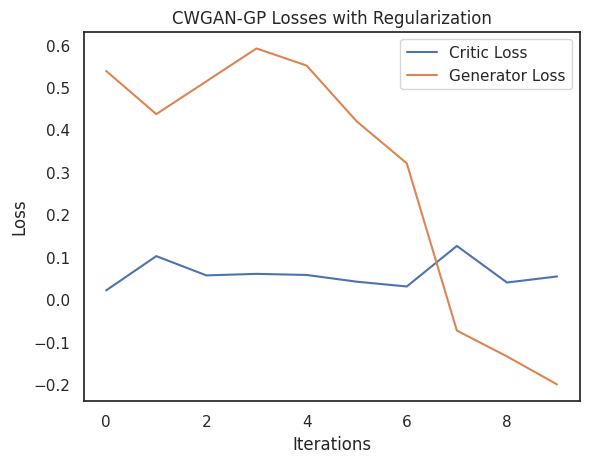

In [55]:
plt.Figure(figsize=(20, 20), dpi=PLOT_DPI)

plt.plot(gan_losses["critic"], label="Critic Loss")
plt.plot(gan_losses["generator"], label="Generator Loss")
plt.title("CWGAN-GP Losses with Regularization")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()

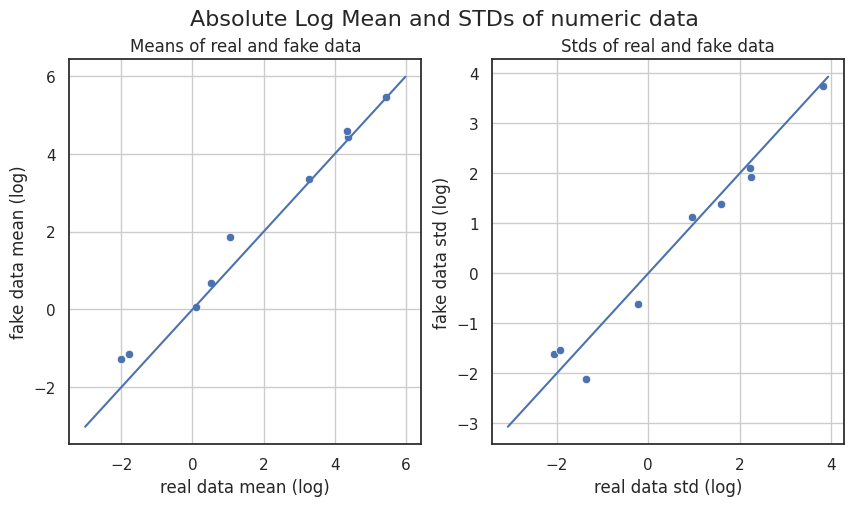

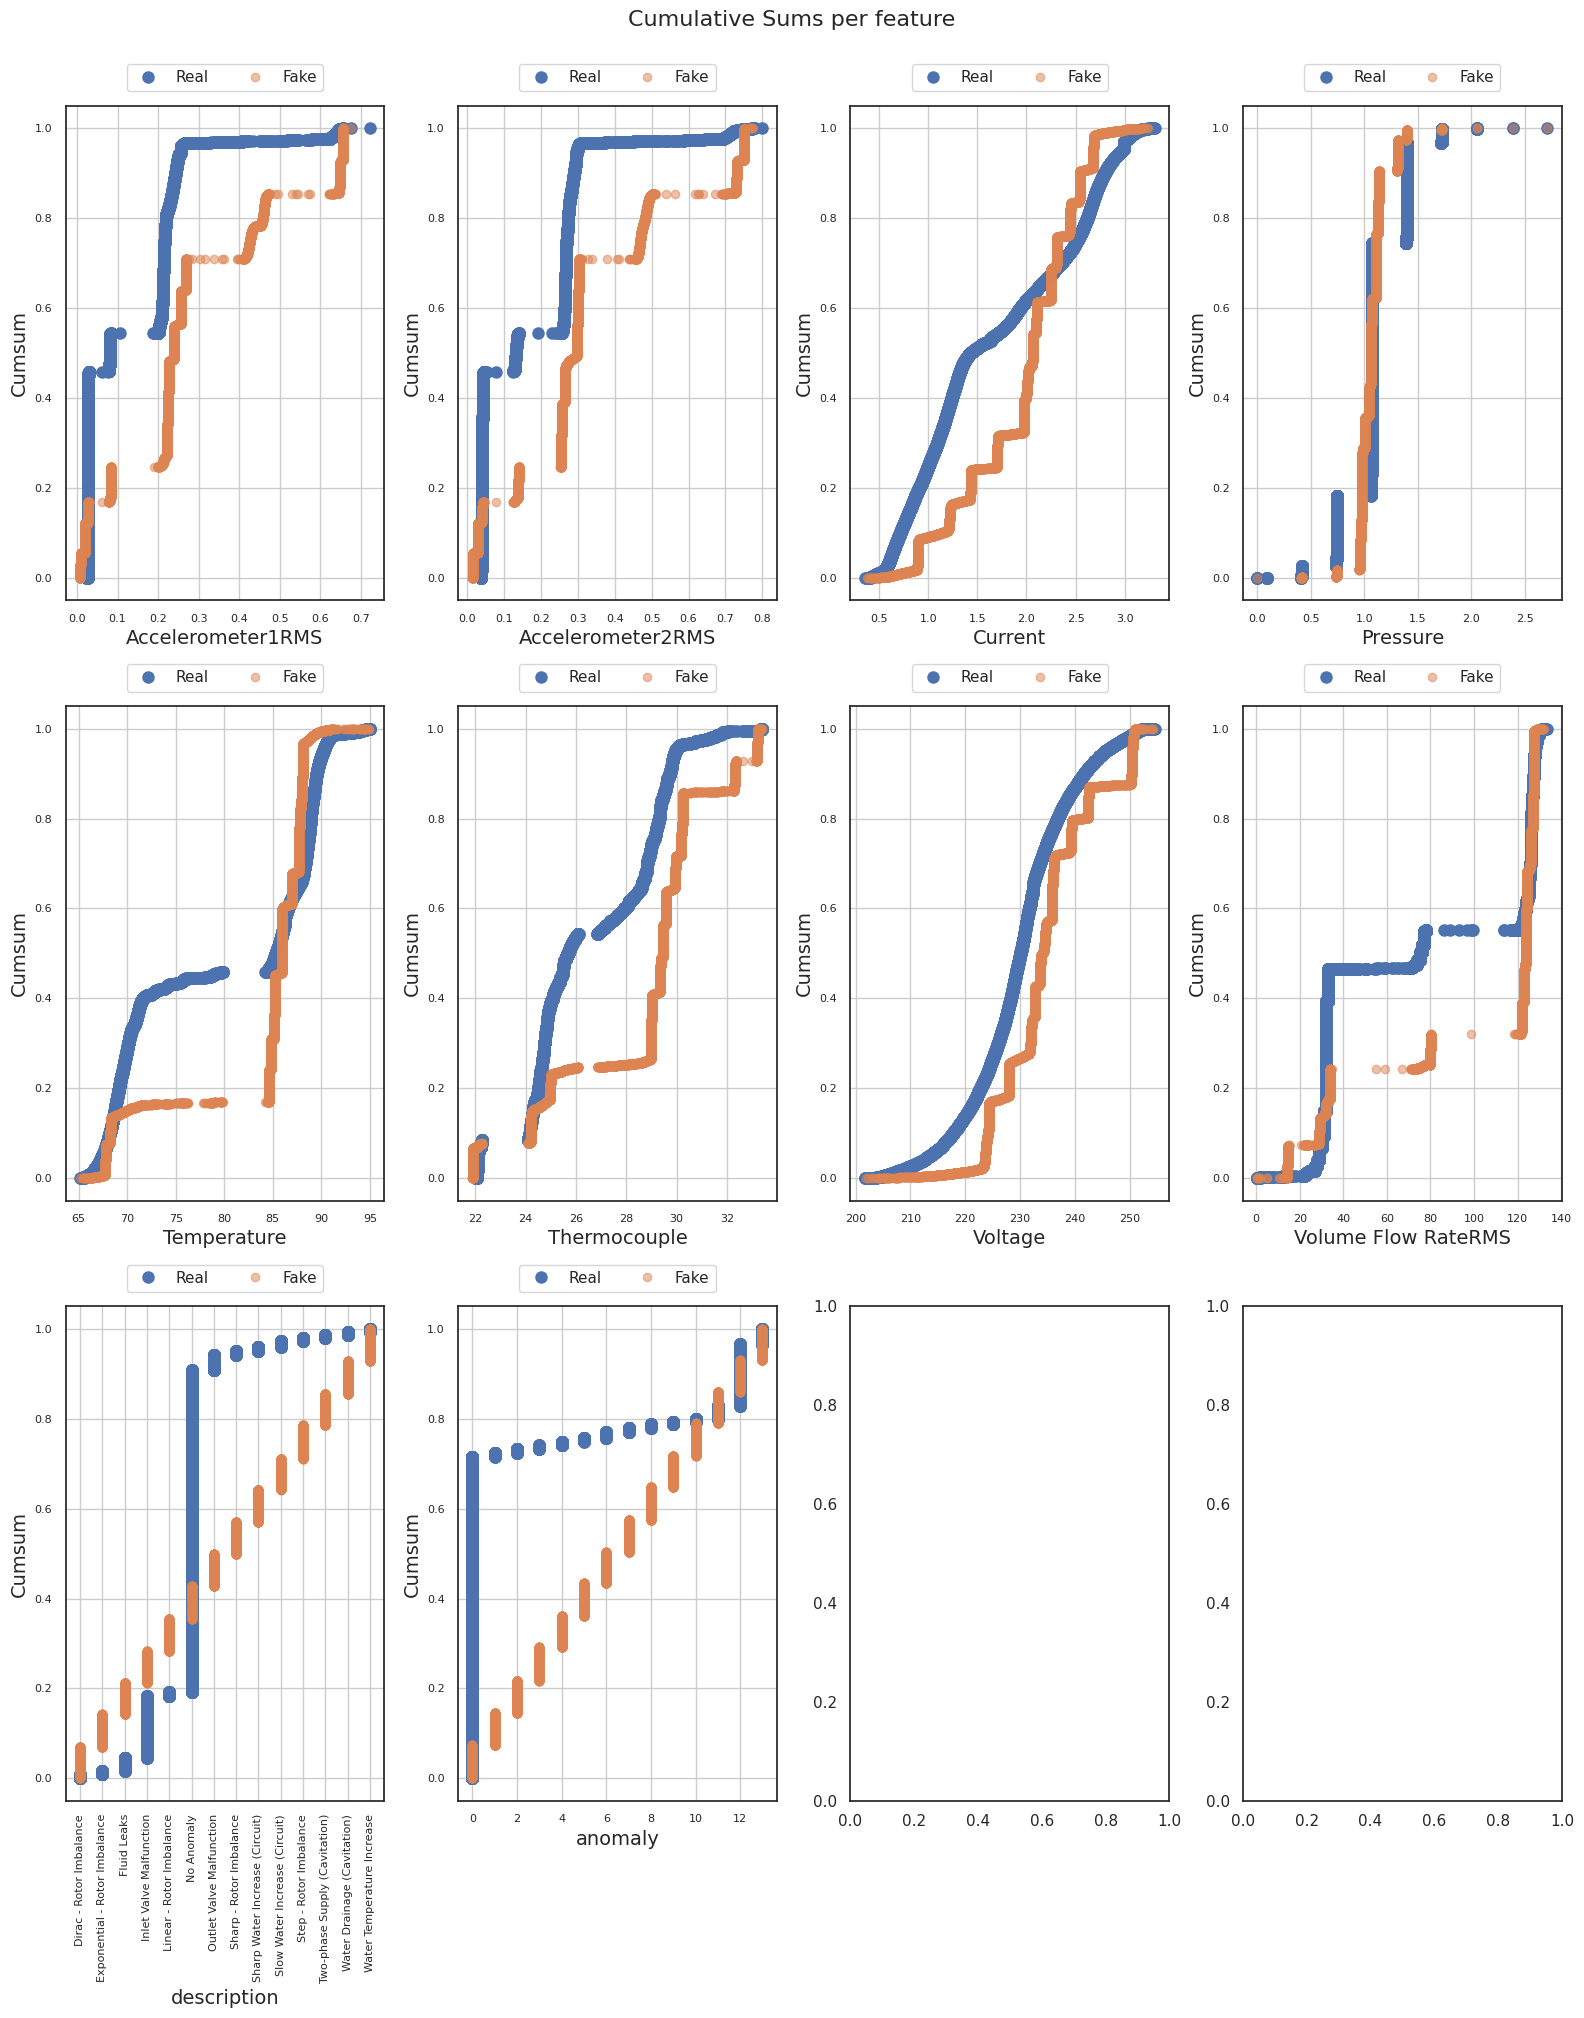

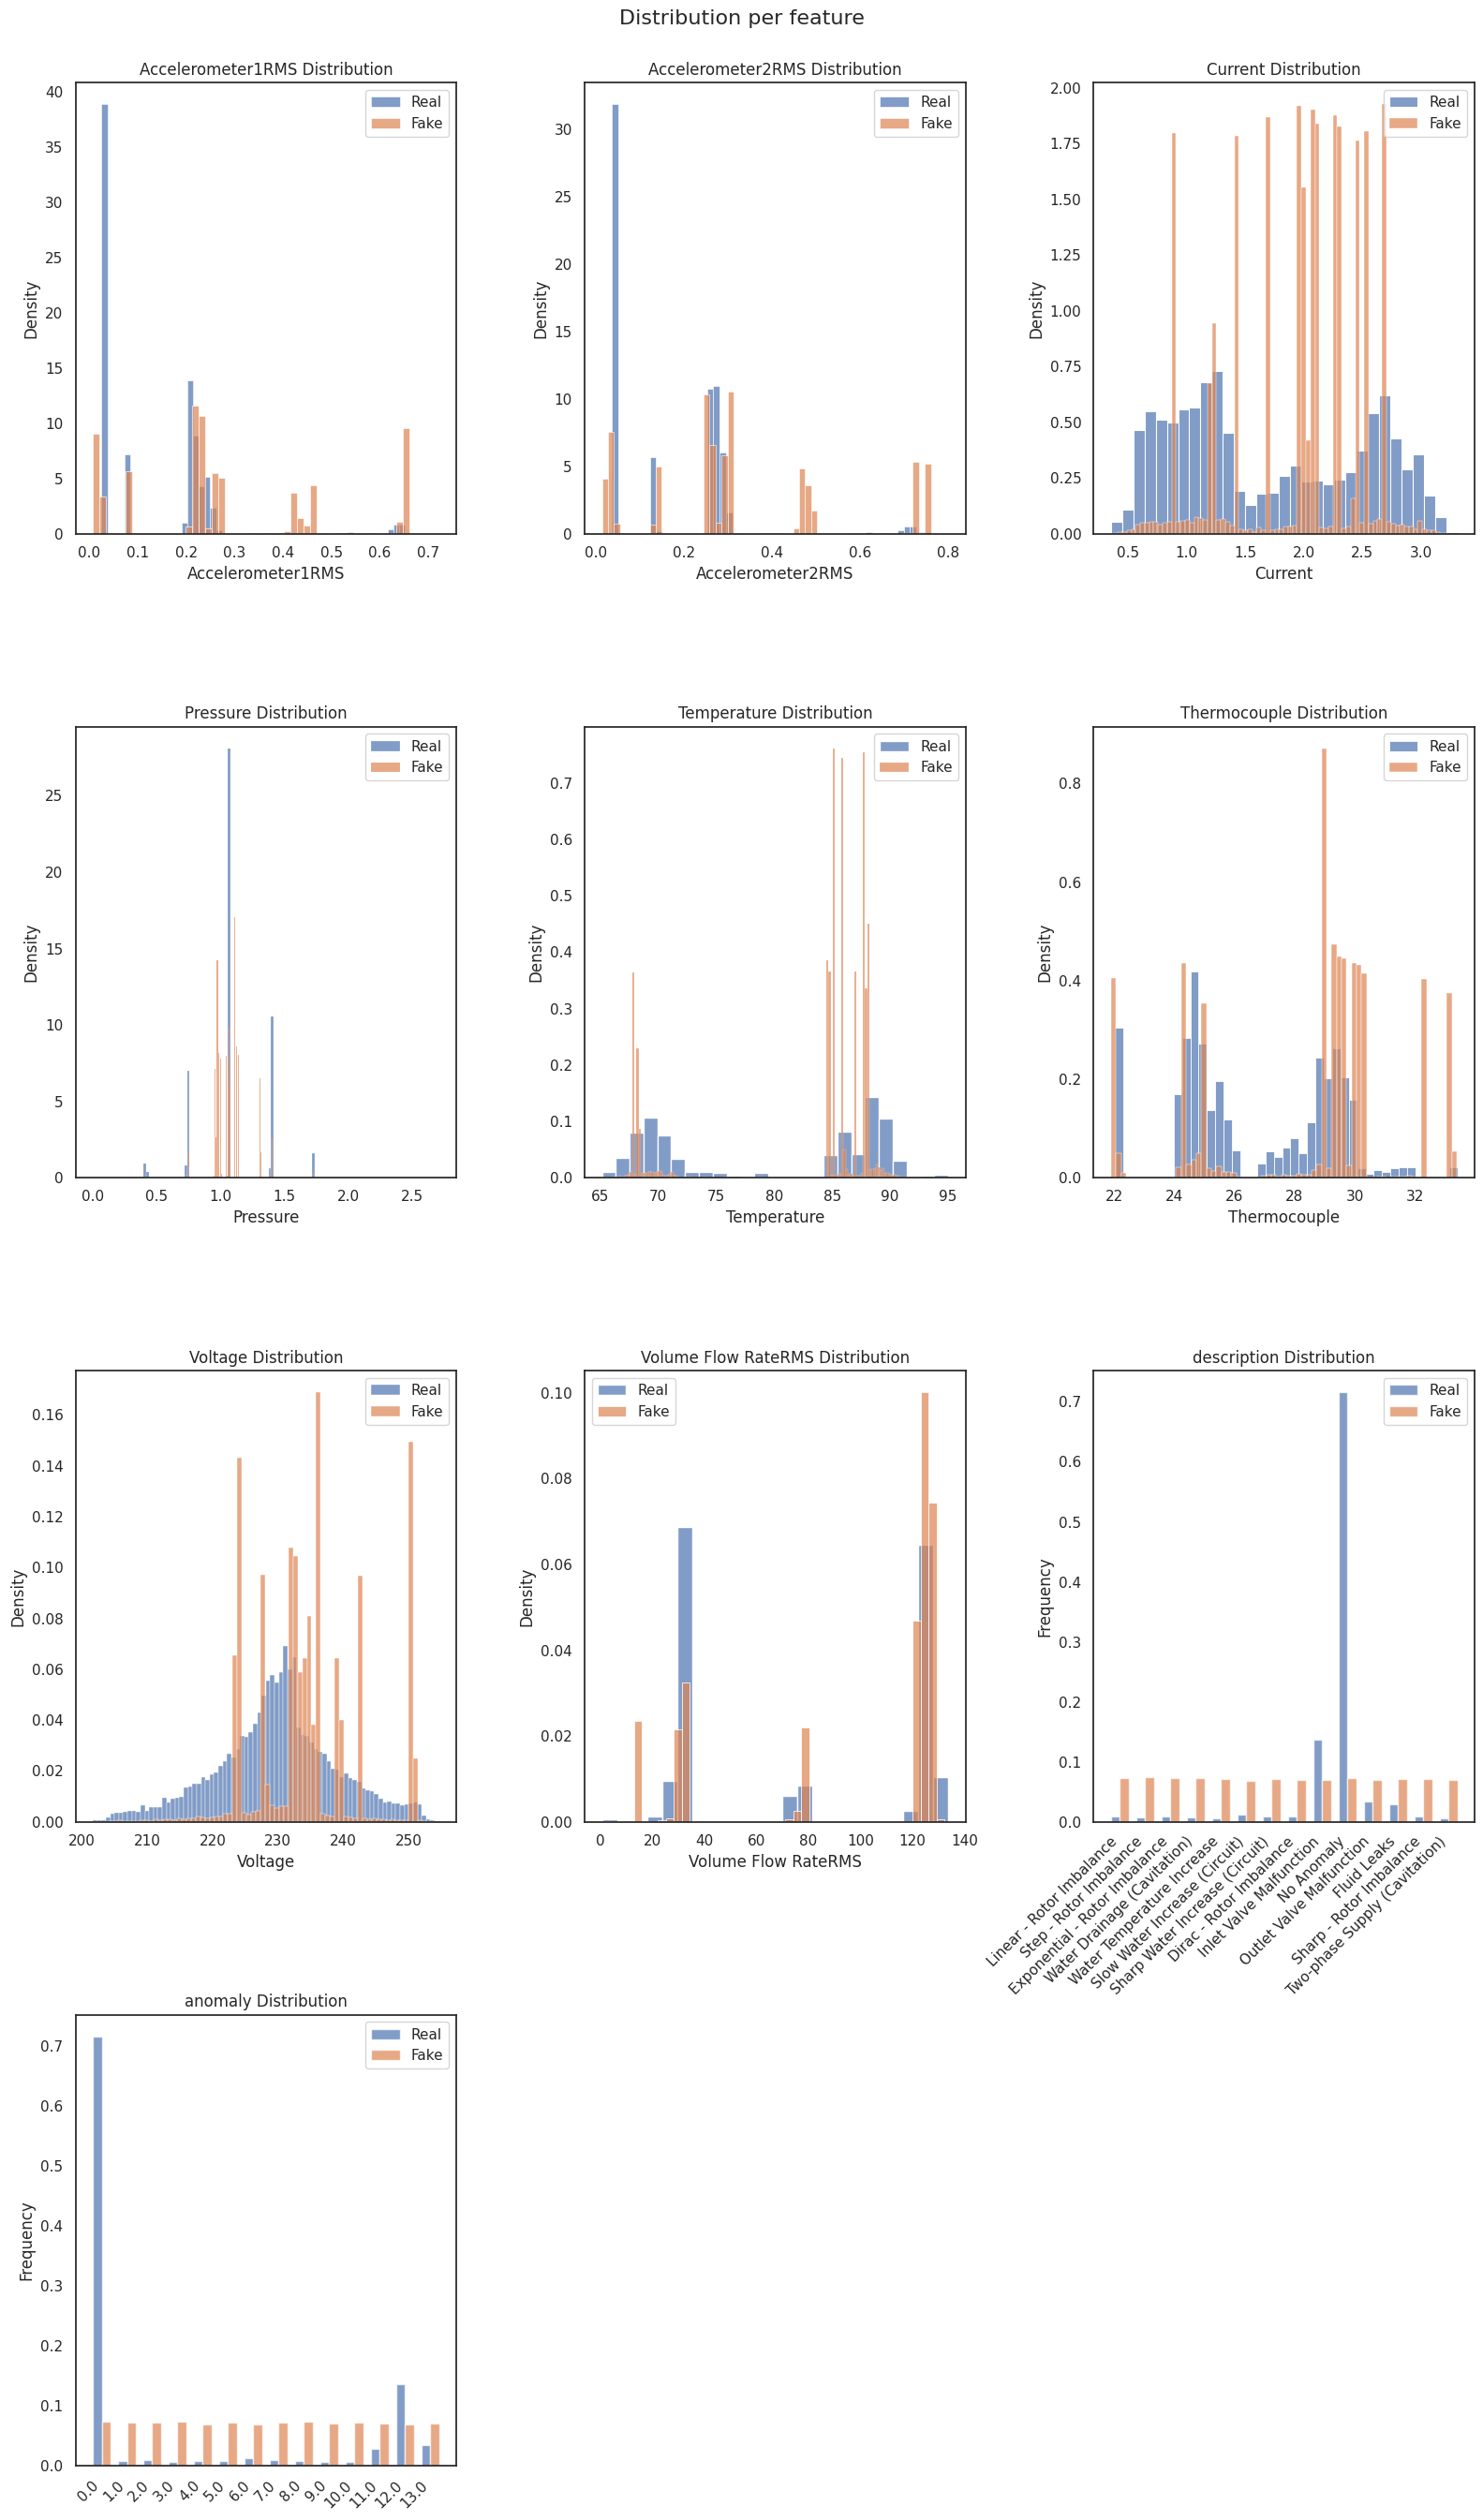

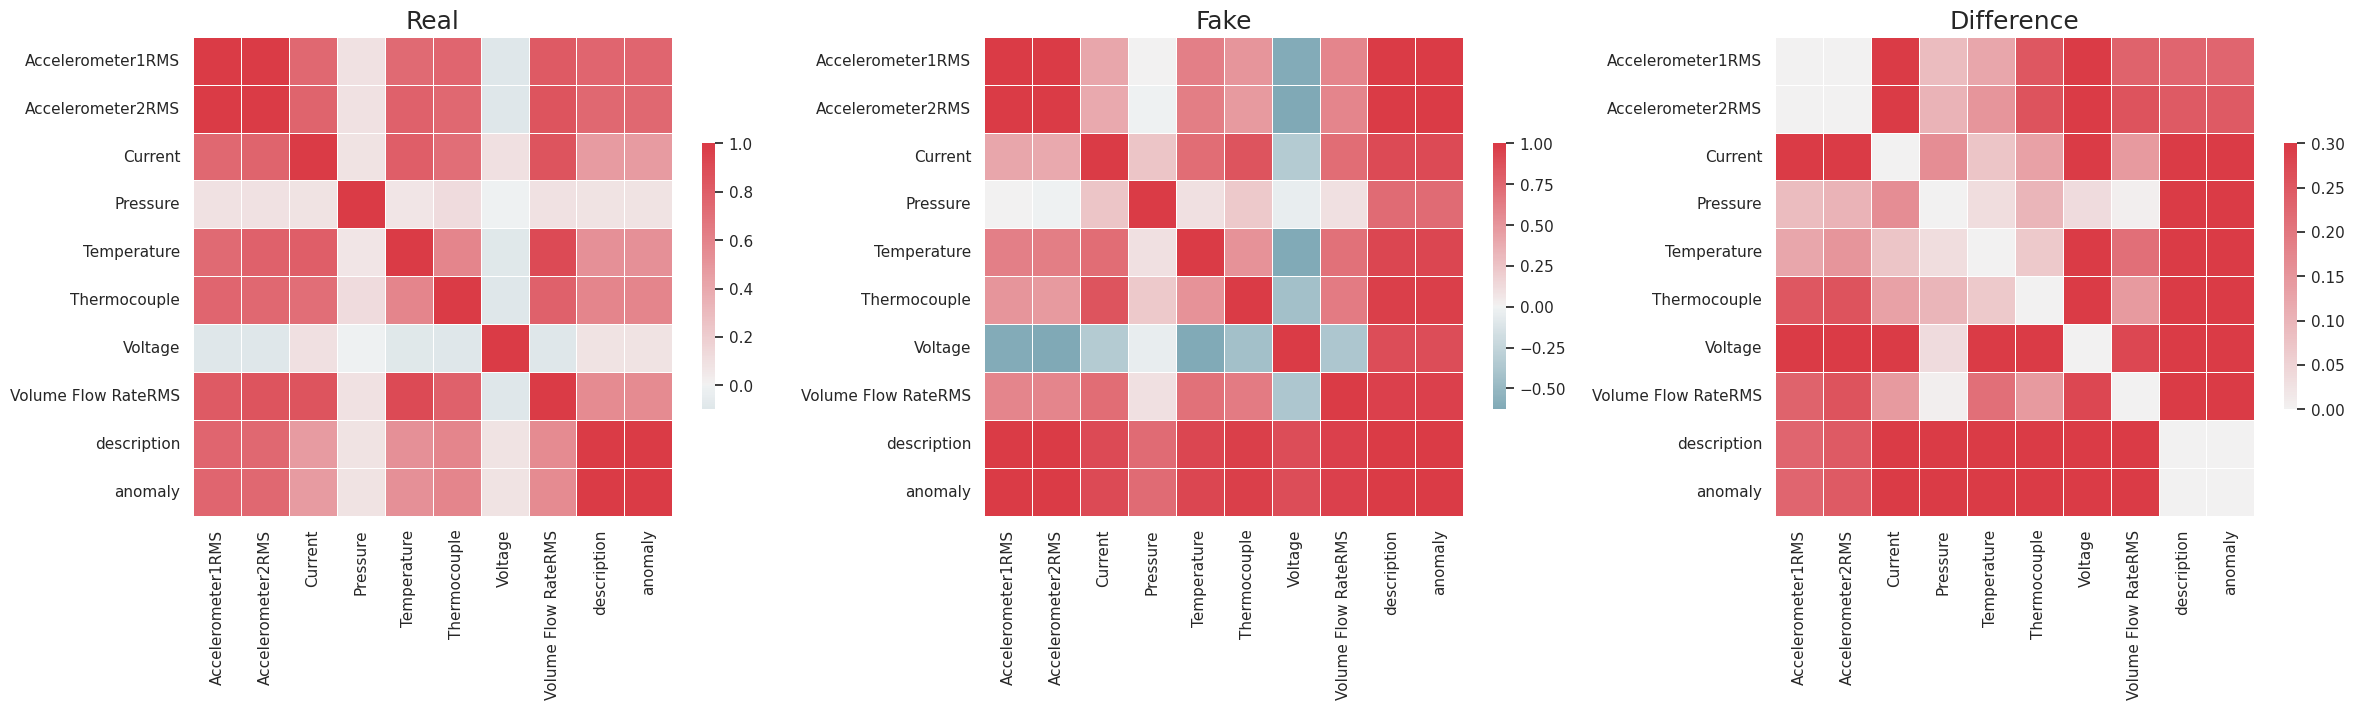

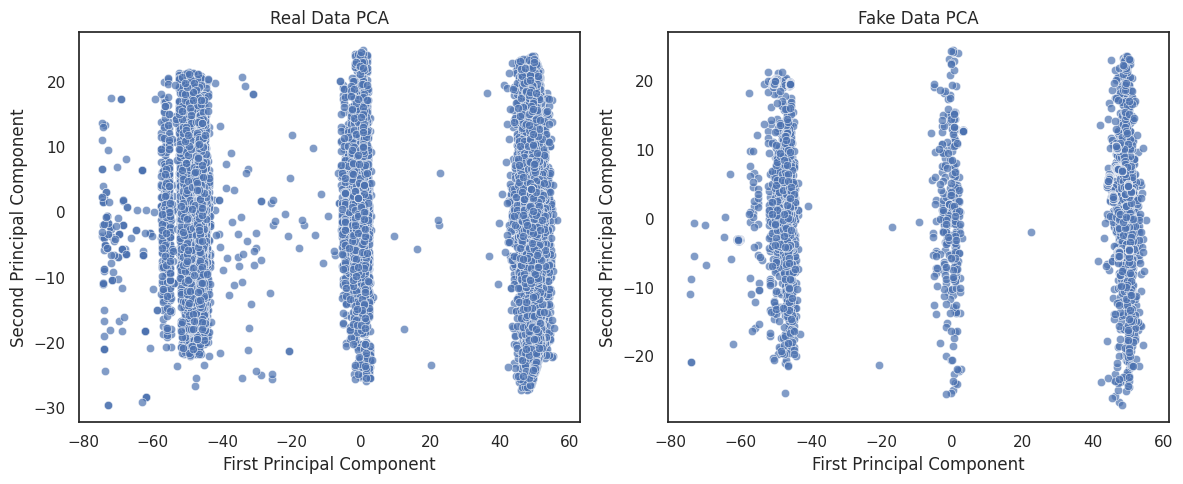

In [56]:
from table_evaluator import TableEvaluator

te = TableEvaluator(df, augmented_samples, cat_cols=["anomaly", "description"])
te.visual_evaluation()